In [2]:
# Cell 1: Explore the dataset structure
import os

dataset_path = '/kaggle/input/'

# List all directories and files
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        filepath = os.path.join(root, file)
        size_mb = os.path.getsize(filepath) / (1024 * 1024)
        print(f"{filepath}  —  {size_mb:.1f} MB")


/kaggle/input/datasets/himadri07/ciciot2023/CICIOT23/validation/validation.csv  —  331.8 MB
/kaggle/input/datasets/himadri07/ciciot2023/CICIOT23/test/test.csv  —  331.8 MB
/kaggle/input/datasets/himadri07/ciciot2023/CICIOT23/train/train.csv  —  1548.2 MB


In [3]:
# Cell 2: Peek at the dataset structure (load only first 1000 rows)
import pandas as pd

train_path = '/kaggle/input/datasets/himadri07/ciciot2023/CICIOT23/train/train.csv'

# Load just 1000 rows to see the structure
sample = pd.read_csv(train_path, nrows=1000)

print("Shape:", sample.shape)
print("\nColumns:")
print(sample.columns.tolist())
print("\nFirst 5 rows:")
sample.head()


Shape: (1000, 47)

Columns:
['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label']

First 5 rows:


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,757.00,6.00,64.00,23.671858,23.671858,0.0,0.0,0.0,0.0,...,538.470740,944.00,8.334058e+07,9.5,41.845546,761.456760,305219.322301,0.95,141.55,DDoS-ACK_Fragmentation
1,0.000000,54.00,6.00,64.00,2.393046,2.393046,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.309327e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SYN_Flood
2,0.033982,56.78,6.11,64.64,1.192715,1.192715,0.0,0.0,0.0,0.0,...,1.727526,54.29,8.333086e+07,9.5,10.462813,2.445286,16.853118,0.19,141.55,DDoS-PSHACK_Flood
3,0.000000,0.00,47.00,64.00,9.841972,9.841972,0.0,0.0,0.0,0.0,...,0.000000,592.00,8.370278e+07,9.5,34.409301,0.000000,0.000000,0.00,141.55,Mirai-greeth_flood
4,3.944828,108.00,6.00,64.00,0.506993,0.506993,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.297270e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DoS-SYN_Flood


In [4]:
# Cell 3: Check all unique labels (read only the label column to save memory)
import pandas as pd

train_path = '/kaggle/input/datasets/himadri07/ciciot2023/CICIOT23/train/train.csv'

# Read only the 'label' column in chunks to count all categories
label_counts = pd.Series(dtype=int)

for chunk in pd.read_csv(train_path, usecols=['label'], chunksize=100000):
    counts = chunk['label'].value_counts()
    label_counts = label_counts.add(counts, fill_value=0)

label_counts = label_counts.astype(int).sort_values(ascending=False)

print(f"Total rows: {label_counts.sum():,}")
print(f"Unique labels: {len(label_counts)}\n")
print("Label distribution:")
print(label_counts.to_string())


Total rows: 5,491,971
Unique labels: 34

Label distribution:
label
DDoS-ICMP_Flood            848088
DDoS-UDP_Flood             637558
DDoS-TCP_Flood             528499
DDoS-PSHACK_Flood          481254
DDoS-SYN_Flood             478653
DDoS-RSTFINFlood           475441
DDoS-SynonymousIP_Flood    422083
DoS-UDP_Flood              390422
DoS-TCP_Flood              314174
DoS-SYN_Flood              237573
BenignTraffic              129538
Mirai-greeth_flood         116133
Mirai-udpplain             104814
Mirai-greip_flood           88821
DDoS-ICMP_Fragmentation     53046
MITM-ArpSpoofing            36316
DDoS-UDP_Fragmentation      34169
DDoS-ACK_Fragmentation      33581
DNS_Spoofing                21214
Recon-HostDiscovery         15737
Recon-OSScan                11587
Recon-PortScan               9648
DoS-HTTP_Flood               8487
VulnerabilityScan            4396
DDoS-HTTP_Flood              3371
DDoS-SlowLoris               2757
DictionaryBruteForce         1541
BrowserHijackin

In [5]:
# Cell 4: Create category mapping and build stratified sample (~150k rows)
import pandas as pd
import numpy as np

train_path = '/kaggle/input/datasets/himadri07/ciciot2023/CICIOT23/train/train.csv'

# Define the mapping from original labels to 5 categories
category_map = {
    # Benign
    'BenignTraffic': 'Benign',
    # DDoS
    'DDoS-ICMP_Flood': 'DDoS', 'DDoS-UDP_Flood': 'DDoS', 'DDoS-TCP_Flood': 'DDoS',
    'DDoS-PSHACK_Flood': 'DDoS', 'DDoS-SYN_Flood': 'DDoS', 'DDoS-RSTFINFlood': 'DDoS',
    'DDoS-SynonymousIP_Flood': 'DDoS', 'DDoS-ICMP_Fragmentation': 'DDoS',
    'DDoS-UDP_Fragmentation': 'DDoS', 'DDoS-ACK_Fragmentation': 'DDoS',
    'DDoS-HTTP_Flood': 'DDoS', 'DDoS-SlowLoris': 'DDoS',
    # DoS
    'DoS-UDP_Flood': 'DoS', 'DoS-TCP_Flood': 'DoS',
    'DoS-SYN_Flood': 'DoS', 'DoS-HTTP_Flood': 'DoS',
    # Botnet
    'Mirai-greeth_flood': 'Botnet', 'Mirai-udpplain': 'Botnet',
    'Mirai-greip_flood': 'Botnet',
    # Brute Force
    'DictionaryBruteForce': 'BruteForce',
}

# Load in chunks, map labels, keep only our 5 categories
frames = []
for chunk in pd.read_csv(train_path, chunksize=200000):
    chunk = chunk[chunk['label'].isin(category_map.keys())].copy()
    chunk['attack_category'] = chunk['label'].map(category_map)
    frames.append(chunk)

df_full = pd.concat(frames, ignore_index=True)
print(f"Total rows after filtering: {len(df_full):,}")
print(f"\nCategory distribution (full):")
print(df_full['attack_category'].value_counts().to_string())

# Stratified sample: take up to 250,000 per class (all for BruteForce since < 30k)
sample_per_class = 250000
sampled_frames = []
for cat in df_full['attack_category'].unique():
    cat_data = df_full[df_full['attack_category'] == cat]
    if len(cat_data) <= sample_per_class:
        sampled_frames.append(cat_data)  # Take all (BruteForce)
    else:
        sampled_frames.append(cat_data.sample(n=sample_per_class, random_state=42))

df = pd.concat(sampled_frames, ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle

print(f"\n--- SAMPLED DATASET ---")
print(f"Total rows: {len(df):,}")
print(f"\nCategory distribution (sampled):")
print(df['attack_category'].value_counts().to_string())


Total rows after filtering: 5,390,003

Category distribution (full):
attack_category
DDoS          3998500
DoS            950656
Botnet         309768
Benign         129538
BruteForce       1541

--- SAMPLED DATASET ---
Total rows: 881,079

Category distribution (sampled):
attack_category
DoS           250000
Botnet        250000
DDoS          250000
Benign        129538
BruteForce      1541


In [6]:
# Cell 5: Data Preprocessing — clean nulls, infinites, drop non-numeric, normalize
import numpy as np

# Drop the original 'label' column (we now use 'attack_category')
df = df.drop(columns=['label'])

# Check for missing and infinite values BEFORE cleaning
print("=== BEFORE CLEANING ===")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Infinite values: {np.isinf(df.select_dtypes(include=[np.number])).sum().sum()}")

# Replace infinites with NaN, then drop rows with any NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"\n=== AFTER CLEANING ===")
print(f"Rows remaining: {len(df):,}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Infinite values: {np.isinf(df.select_dtypes(include=[np.number])).sum().sum()}")
print(f"\nCategory distribution after cleaning:")
print(df['attack_category'].value_counts().to_string())
print(f"\nData types:\n{df.dtypes.value_counts().to_string()}")
print(f"\nBasic stats:")
df.describe().round(2)


=== BEFORE CLEANING ===
Missing values: 0
Infinite values: 0

=== AFTER CLEANING ===
Rows remaining: 881,079
Missing values: 0
Infinite values: 0

Category distribution after cleaning:
attack_category
DoS           250000
Botnet        250000
DDoS          250000
Benign        129538
BruteForce      1541

Data types:
float64    46
object      1

Basic stats:


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight
count,881079.00,881079.00,881079.00,881079.00,881079.00,881079.00,881079.00,881079.00,881079.00,881079.00,...,881079.00,881079.00,881079.00,8.810790e+05,881079.00,881079.00,881079.00,881079.00,881079.00,881079.00
mean,8.20,302858.49,16.20,72.41,8347.57,8347.57,0.00,0.03,0.13,0.04,...,294.33,85.49,294.17,8.332172e+07,9.50,20.32,120.78,100791.19,0.19,141.54
std,249.03,852918.72,15.16,27.11,92466.59,92466.59,0.00,0.18,0.34,0.19,...,372.22,284.56,373.56,3.218198e+07,1.55,13.01,402.55,699664.36,0.33,39.81
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,42.00,0.00,42.00,0.000000e+00,1.00,9.17,0.00,0.00,0.00,1.00
25%,0.00,53.46,6.00,64.00,3.00,3.00,0.00,0.00,0.00,0.00,...,54.00,0.00,54.00,8.300689e+07,9.50,10.39,0.00,0.00,0.00,141.55
50%,0.03,108.00,7.10,64.00,24.33,24.33,0.00,0.00,0.00,0.00,...,55.47,0.00,55.76,8.312881e+07,9.50,10.52,0.00,0.00,0.00,141.55
75%,2.64,36574.50,17.00,65.27,393.49,393.49,0.00,0.00,0.00,0.00,...,554.00,18.60,554.00,8.367741e+07,9.50,33.29,26.23,1937.31,0.19,141.55
max,99435.76,9665361.00,47.00,255.00,8388608.00,8388608.00,0.05,1.00,1.00,1.00,...,11600.47,9302.37,13098.00,1.666019e+08,15.00,145.39,13155.54,96708369.53,1.00,244.60


In [7]:
# Cell 6: Feature scaling, train/test split, and SMOTE balancing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

# Separate features and target
X = df.drop(columns=['attack_category'])
y = df['attack_category']

# Encode labels: text → numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Label encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} = {cls}")

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nBefore SMOTE:")
print(f"  Train size: {len(X_train):,}")
print(f"  Test size:  {len(X_test):,}")

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"  Train size: {len(X_train_res):,}")
print(f"  Training class distribution:")
import pandas as pd
smote_dist = pd.Series(y_train_res).map(dict(enumerate(le.classes_))).value_counts()
print(smote_dist.to_string())


Label encoding:
  0 = Benign
  1 = Botnet
  2 = BruteForce
  3 = DDoS
  4 = DoS

Before SMOTE:
  Train size: 704,863
  Test size:  176,216

After SMOTE:
  Train size: 1,000,000
  Training class distribution:
Botnet        200000
Benign        200000
DoS           200000
DDoS          200000
BruteForce    200000


In [8]:
# Cell 7: Train Random Forest (primary) and KNN (baseline)
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
import time

# --- RANDOM FOREST (Primary Model) ---
print("=" * 50)
print("TRAINING RANDOM FOREST...")
print("=" * 50)

rf_start = time.time()
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_res, y_train_res)
rf_time = time.time() - rf_start

rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Training time: {rf_time:.1f} seconds")
print(f"Test Accuracy: {rf_accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=le.classes_))

# --- KNN (Baseline Comparison) ---
print("=" * 50)
print("TRAINING KNN (Baseline)...")
print("=" * 50)

knn_start = time.time()
knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_model.fit(X_train_res, y_train_res)
knn_time = time.time() - knn_start

knn_pred = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_pred)

print(f"Training time: {knn_time:.1f} seconds")
print(f"Test Accuracy: {knn_accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, knn_pred, target_names=le.classes_))

# --- COMPARISON ---
print("=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
print(f"Random Forest:  Accuracy = {rf_accuracy:.4f}  |  Time = {rf_time:.1f}s")
print(f"KNN (Baseline): Accuracy = {knn_accuracy:.4f}  |  Time = {knn_time:.1f}s")


TRAINING RANDOM FOREST...
Training time: 148.1 seconds
Test Accuracy: 0.9974

Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      0.99      0.99     25908
      Botnet       1.00      1.00      1.00     50000
  BruteForce       0.44      0.84      0.57       308
        DDoS       1.00      1.00      1.00     50000
         DoS       1.00      1.00      1.00     50000

    accuracy                           1.00    176216
   macro avg       0.89      0.97      0.91    176216
weighted avg       1.00      1.00      1.00    176216

TRAINING KNN (Baseline)...
Training time: 0.1 seconds
Test Accuracy: 0.9629

Classification Report:
              precision    recall  f1-score   support

      Benign       0.99      0.96      0.98     25908
      Botnet       1.00      1.00      1.00     50000
  BruteForce       0.15      0.56      0.23       308
        DDoS       0.96      0.93      0.95     50000
         DoS       0.94      0.96      

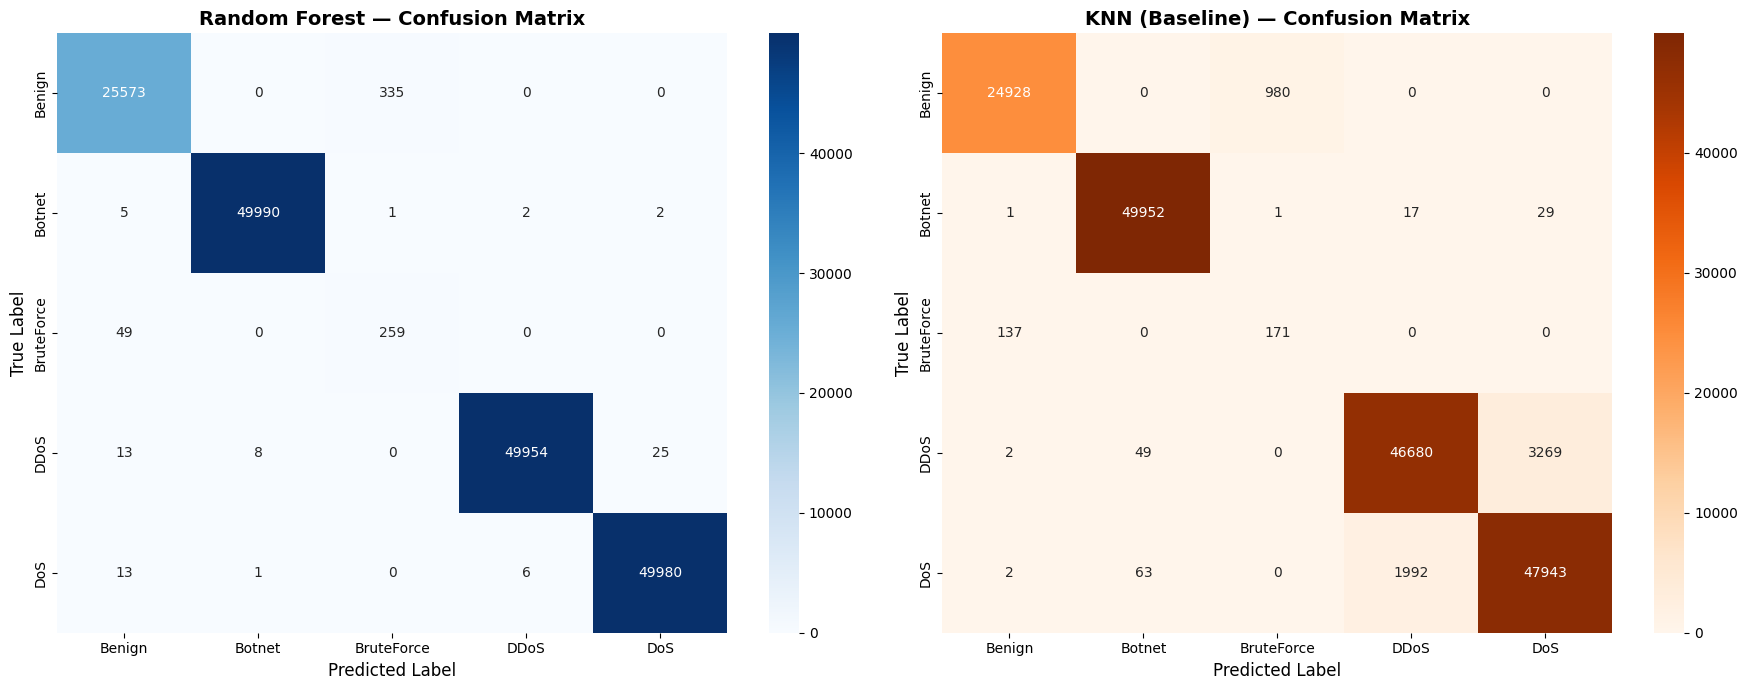

✅ Saved: confusion_matrices.png


In [9]:
# Cell 8: Confusion Matrix — Random Forest
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# RF Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Random Forest — Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)

# KNN Confusion Matrix
cm_knn = confusion_matrix(y_test, knn_pred)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('KNN (Baseline) — Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: confusion_matrices.png")


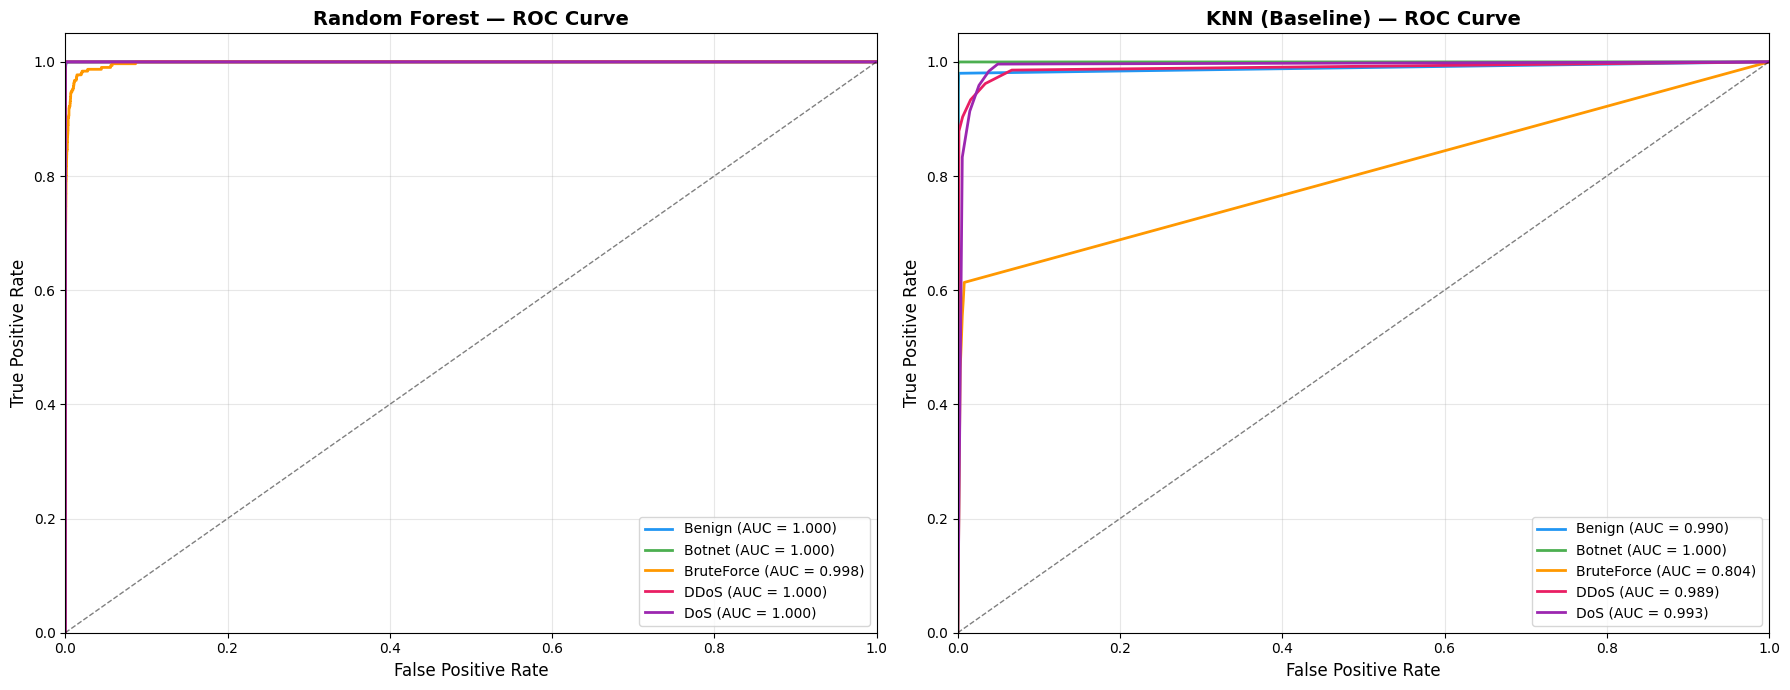

✅ Saved: roc_curves.png


In [10]:
# Cell 9: ROC Curve (Multi-class, One-vs-Rest)
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the test labels for multi-class ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])

# Get probability scores from both models
rf_proba = rf_model.predict_proba(X_test)
knn_proba = knn_model.predict_proba(X_test)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

for idx, (proba, title, ax) in enumerate([
    (rf_proba, 'Random Forest — ROC Curve', axes[0]),
    (knn_proba, 'KNN (Baseline) — ROC Curve', axes[1])
]):
    for i, cls in enumerate(le.classes_):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors[i], lw=2, label=f'{cls} (AUC = {roc_auc:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: roc_curves.png")


In [11]:
# Cell 10: Export trained Random Forest and Scaler for Windows simulation
import joblib

# We need the scaler too, so the simulation script can scale incoming synthetic traffic exactly like the training data
joblib.dump(rf_model, 'ids_rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("✅ Saved: ids_rf_model.pkl")
print("✅ Saved: scaler.pkl")
print("\n🎉 KAGGLE PHASE COMPLETE! Download these 4 files from the right sidebar ('Output' section):")
print("1. ids_rf_model.pkl")
print("2. scaler.pkl")
print("3. confusion_matrices.png")
print("4. roc_curves.png")


✅ Saved: ids_rf_model.pkl
✅ Saved: scaler.pkl

🎉 KAGGLE PHASE COMPLETE! Download these 4 files from the right sidebar ('Output' section):
1. ids_rf_model.pkl
2. scaler.pkl
3. confusion_matrices.png
4. roc_curves.png
